To demonstrate ``AAPredPlot().hist()``, we fit a model and obtain per-sample prediction scores:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

import numpy as np
aapred = aa.AAPred(random_state=42)
aapred.fit(X, labels)
pred, _ = aapred.predict_proba(X)

The class-separated histogram shows how the scores of the two classes are distributed, with an optional decision threshold:

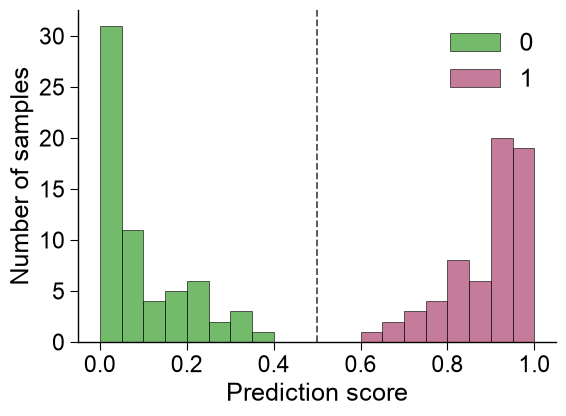

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.hist(pred, labels=labels, thresholds=[0.5])
plt.tight_layout()
plt.show()